In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Set plotting style
sns.set_style("whitegrid")

# --- 1. Load Data ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id'] 

try:
    df_raw = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df_raw)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. Minimal Cleaning for EDA ---
# Drop ID columns
df_eda = df_raw.drop(columns=DROP_COLUMNS, errors='ignore')

# Fill target NaN values so we can plot them
# We create a new 'anomaly_name' column for our readable plots
df_eda['anomaly_name'] = df_eda[TARGET_COLUMN].fillna('Normal')

# --- 3. Initial Inspection ---
print("\n--- df.info() ---")
df_eda.info()

print("\n--- df.describe() (Numerical Features) ---")
# Get stats for numerical columns
print(df_eda.describe())

print("\n--- df.head() ---")
print(df_eda.head())

Successfully loaded 78086 rows.

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78086 entries, 0 to 78085
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   timestamp       78086 non-null  object 
 1   domain          78086 non-null  object 
 2   ip_src          78086 non-null  object 
 3   ip_dst          78086 non-null  object 
 4   port            78086 non-null  int64  
 5   protocol        78086 non-null  object 
 6   duration        78086 non-null  float64
 7   bytes_sent      78086 non-null  int64  
 8   bytes_received  78086 non-null  int64  
 9   vpn_usage       78086 non-null  bool   
 10  cell_id         78086 non-null  object 
 11  location_lat    78086 non-null  float64
 12  location_lon    78086 non-null  float64
 13  is_fraud        78086 non-null  int64  
 14  anomaly_type    6246 non-null   object 
 15  anomaly_name    78086 non-null  object 
dtypes: bool(1), float64(3), i

--- 1. Target Variable Distribution ---


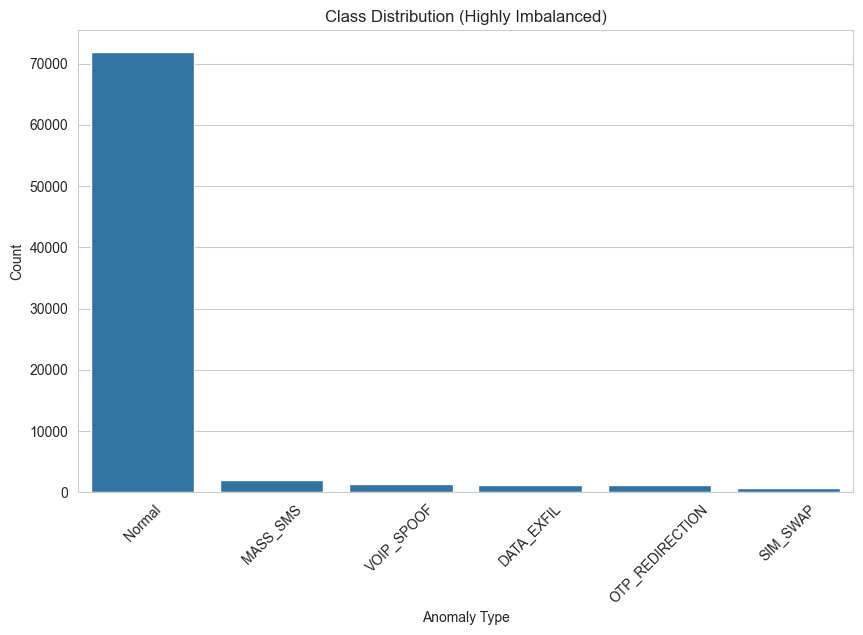

Class Counts:
anomaly_name
Normal             71840
MASS_SMS            2026
VOIP_SPOOF          1287
DATA_EXFIL          1121
OTP_REDIRECTION     1117
SIM_SWAP             695
Name: count, dtype: int64

Class Percentages:
anomaly_name
Normal             92.001127
MASS_SMS            2.594575
VOIP_SPOOF          1.648183
DATA_EXFIL          1.435597
OTP_REDIRECTION     1.430474
SIM_SWAP            0.890044
Name: proportion, dtype: float64


In [27]:
print("--- 1. Target Variable Distribution ---")

plt.figure(figsize=(10, 6))
# We use df_eda['anomaly_name'] which has 'Normal' filled in
sns.countplot(
    data=df_eda,
    x='anomaly_name',
    order=df_eda['anomaly_name'].value_counts().index
)
plt.title("Class Distribution (Highly Imbalanced)")
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Print the exact numbers
print("Class Counts:")
print(df_eda['anomaly_name'].value_counts())
print("\nClass Percentages:")
print(df_eda['anomaly_name'].value_counts(normalize=True) * 100)

--- 2. Numerical Feature Distributions ---


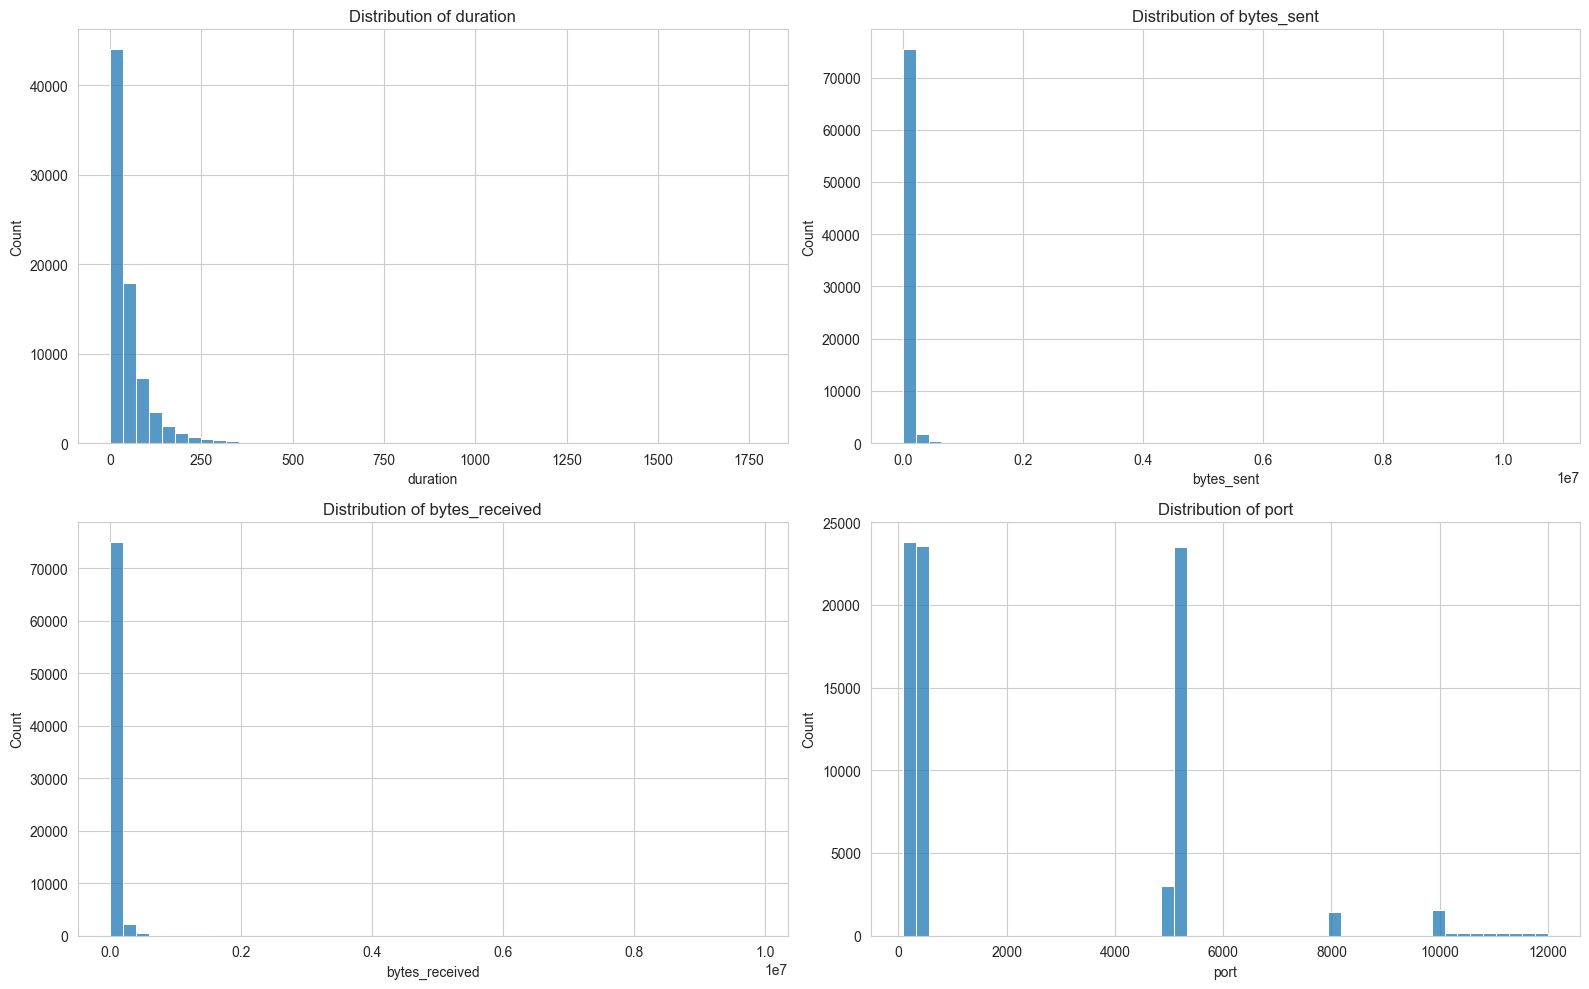


--- 2b. Log-Transformed Numerical Distributions ---


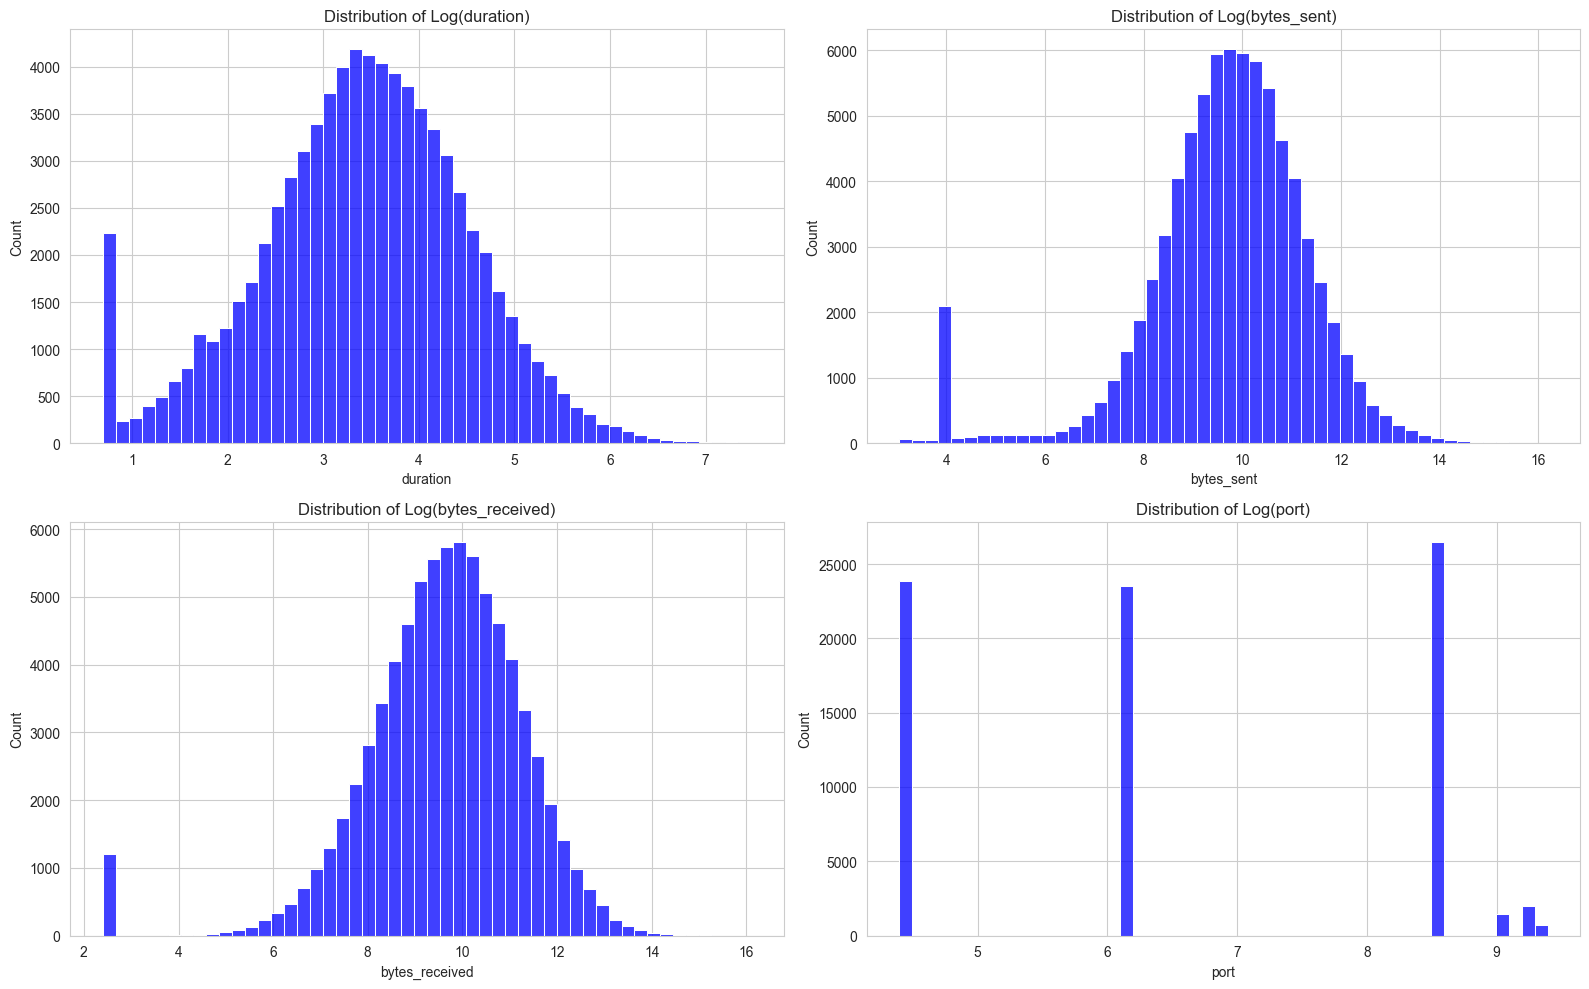

In [28]:
print("--- 2. Numerical Feature Distributions ---")

numerical_features = ['duration', 'bytes_sent', 'bytes_received', 'port']

# Create histograms for each
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Flatten 2x2 array to 1D

for i, feature in enumerate(numerical_features):
    sns.histplot(df_eda[feature], ax=axes[i], bins=50)
    axes[i].set_title(f'Distribution of {feature}')
    
plt.tight_layout()
plt.show()

# --- Log-Transformed Distributions ---
# The plots above are likely skewed. Let's try a log transform.
print("\n--- 2b. Log-Transformed Numerical Distributions ---")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    # Use np.log1p (log(x+1)) to handle zero values
    log_transformed = np.log1p(df_eda[feature])
    sns.histplot(log_transformed, ax=axes[i], bins=50, color='blue')
    axes[i].set_title(f'Distribution of Log({feature})')

plt.tight_layout()
plt.show()

--- 3. Numerical Features vs. Target (Box Plots) ---


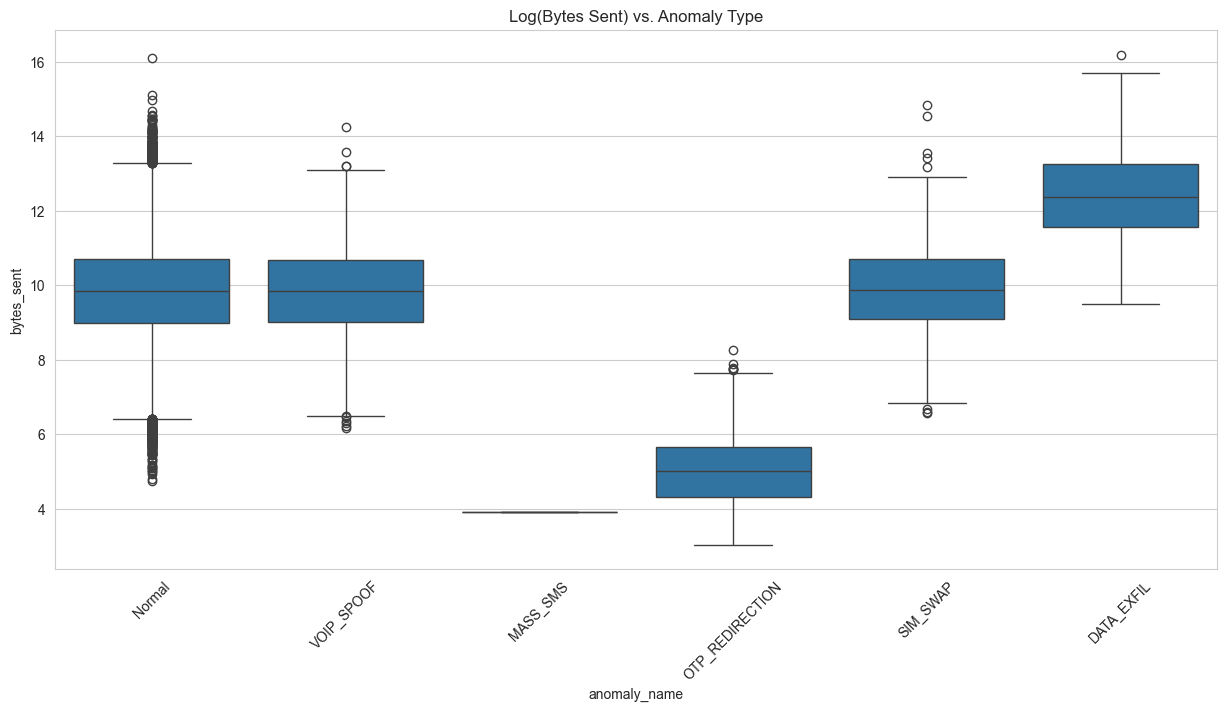

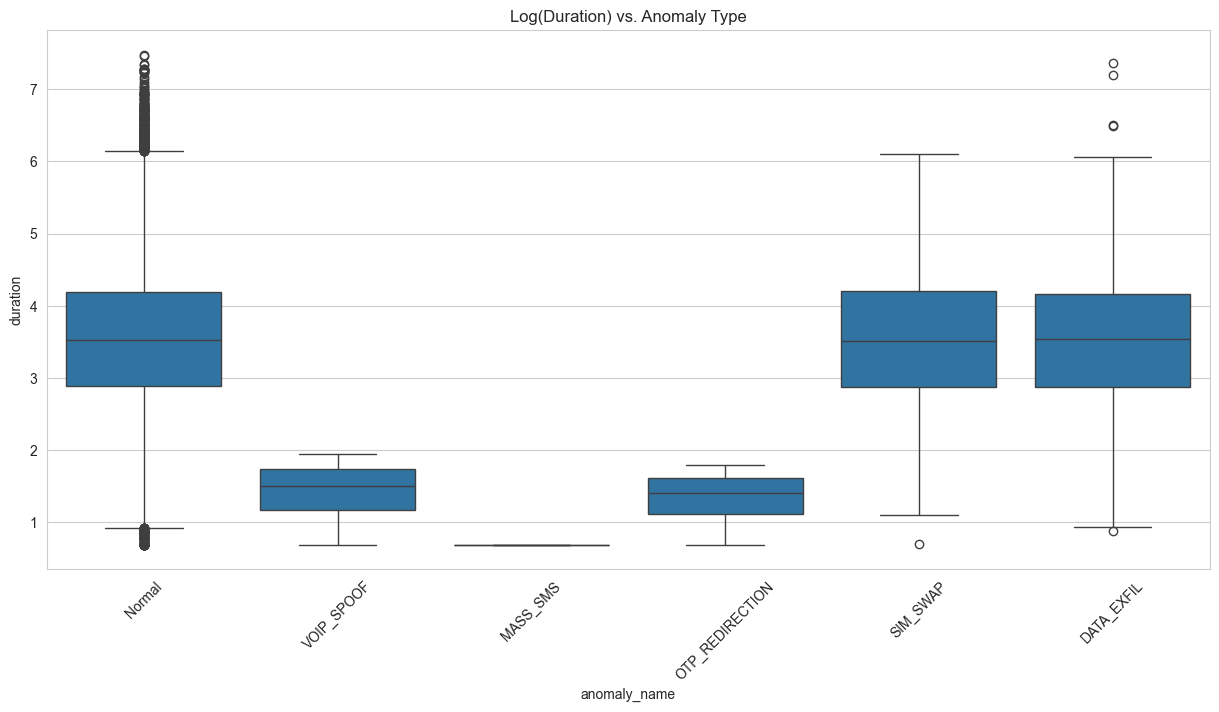

In [29]:
print("--- 3. Numerical Features vs. Target (Box Plots) ---")

# --- Bytes Sent ---
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df_eda,
    x='anomaly_name',
    y=np.log1p(df_eda['bytes_sent']) # Use log for better visualization
)
plt.title("Log(Bytes Sent) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()

# --- Duration ---
plt.figure(figsize=(15, 7))
sns.boxplot(
    data=df_eda,
    x='anomaly_name',
    y=np.log1p(df_eda['duration']) # Use log for better visualization
)
plt.title("Log(Duration) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()

--- 4. Categorical Feature Analysis ---
VPN Usage % by Anomaly Type
                   VPN_Off      VPN_On
anomaly_name                          
DATA_EXFIL        0.000000  100.000000
MASS_SMS         98.321816    1.678184
Normal           96.179009    3.820991
OTP_REDIRECTION  95.881826    4.118174
SIM_SWAP         96.834532    3.165468
VOIP_SPOOF       96.736597    3.263403


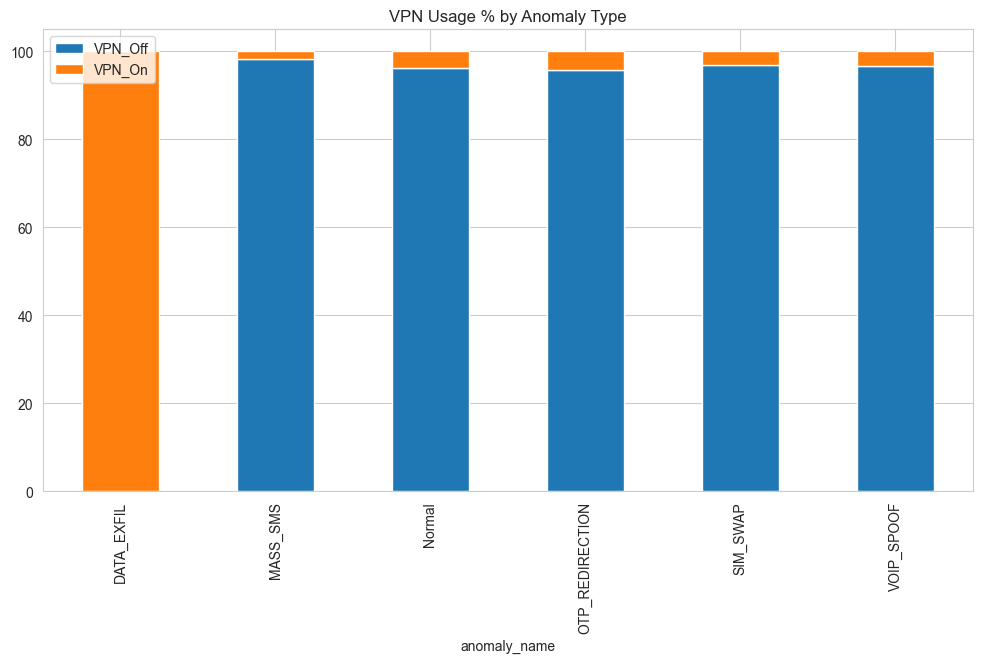


Protocol Distribution by Anomaly Type


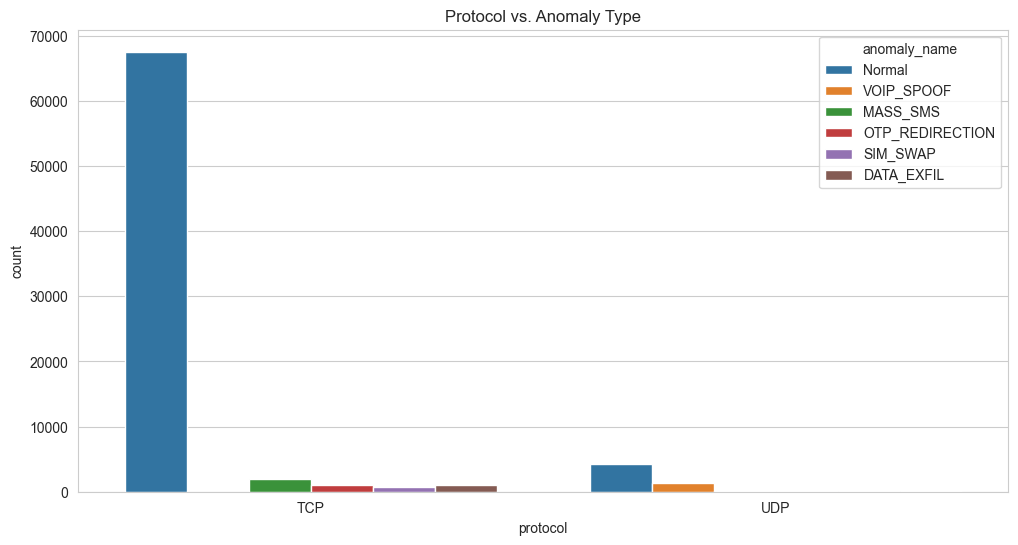


Top 20 Most Frequent Source IPs


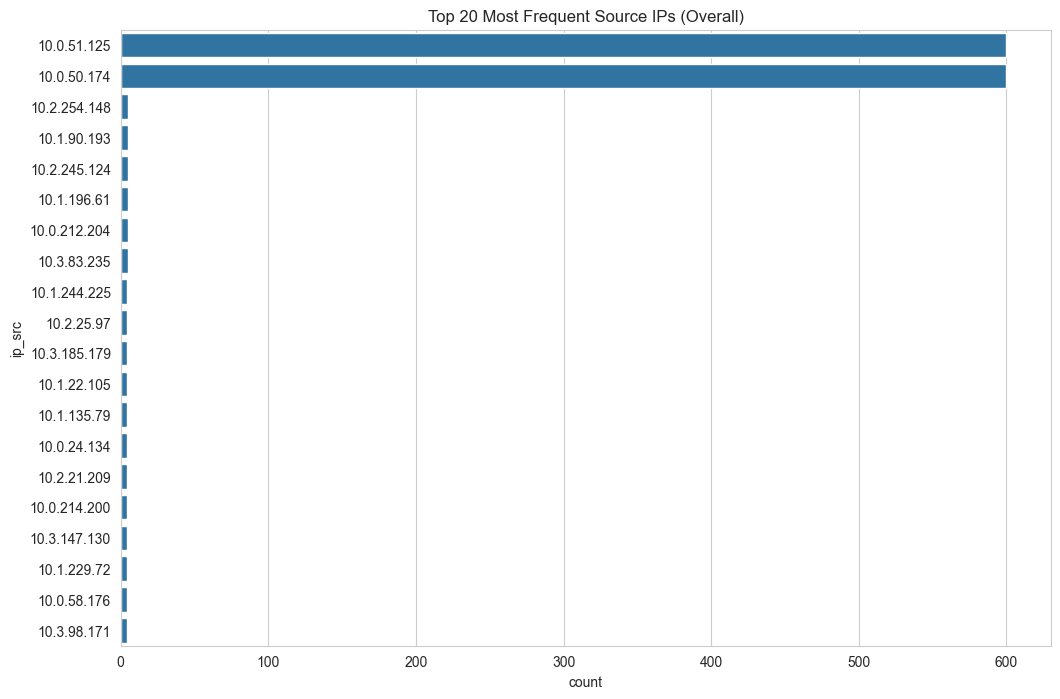

In [30]:
print("--- 4. Categorical Feature Analysis ---")

# --- VPN Usage ---
# (This is the plot we ran before, it's a key part of EDA)
print("VPN Usage % by Anomaly Type")
crosstab_vpn = pd.crosstab(
    df_eda['anomaly_name'],
    df_eda['vpn_usage'],
    normalize='index'
) * 100
crosstab_vpn.columns = ['VPN_Off', 'VPN_On']
print(crosstab_vpn)
crosstab_vpn.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("VPN Usage % by Anomaly Type")
plt.show()

# --- Protocol ---
print("\nProtocol Distribution by Anomaly Type")
plt.figure(figsize=(12, 6))
sns.countplot(data=df_eda, x='protocol', hue='anomaly_name')
plt.title("Protocol vs. Anomaly Type")
plt.show()

# --- Top 20 Source IPs (High-Cardinality) ---
print("\nTop 20 Most Frequent Source IPs")
top_20_ips = df_eda['ip_src'].value_counts().head(20).index
plt.figure(figsize=(12, 8))
sns.countplot(data=df_eda[df_eda['ip_src'].isin(top_20_ips)], y='ip_src', order=top_20_ips)
plt.title("Top 20 Most Frequent Source IPs (Overall)")
plt.show()

--- 5. Relational & Geo-Analysis ---


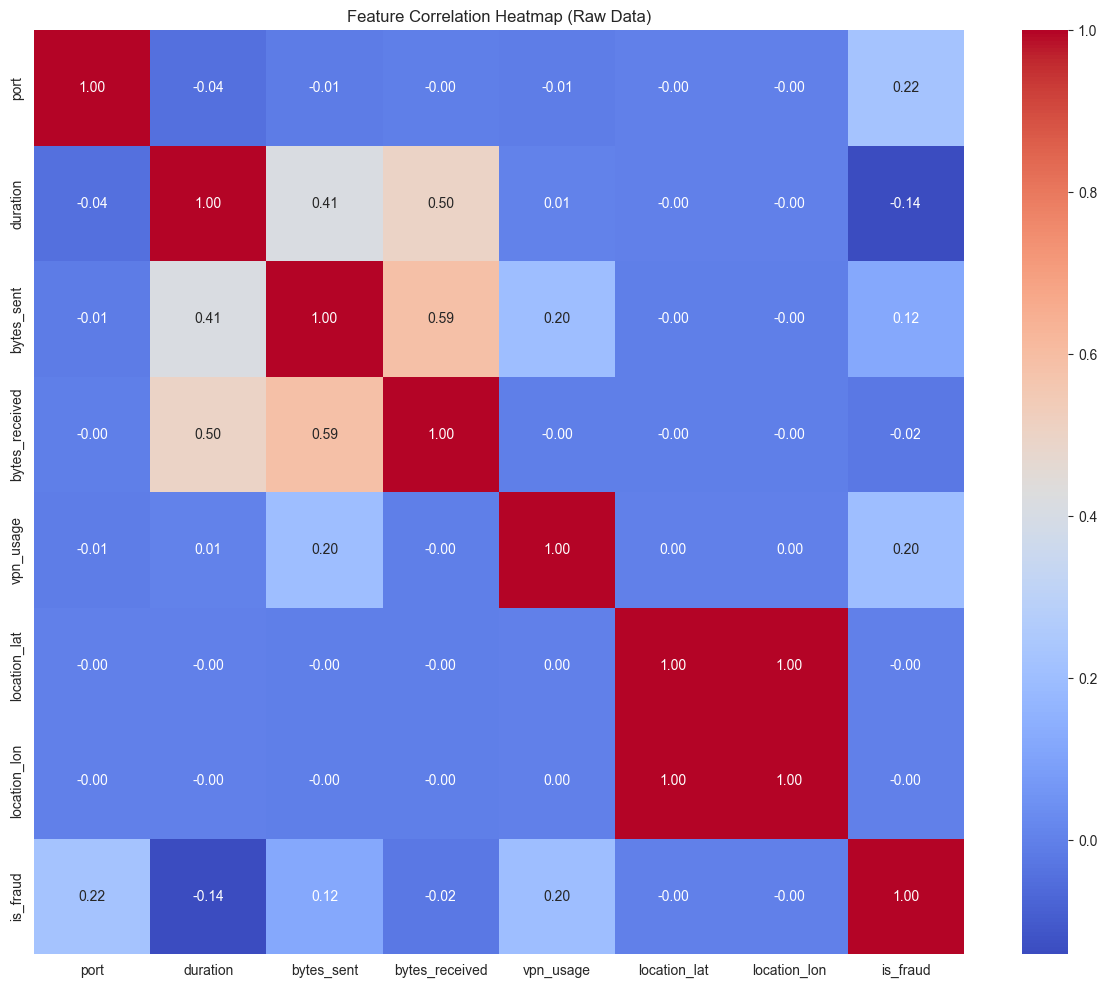


Geographic Distribution of Anomalies


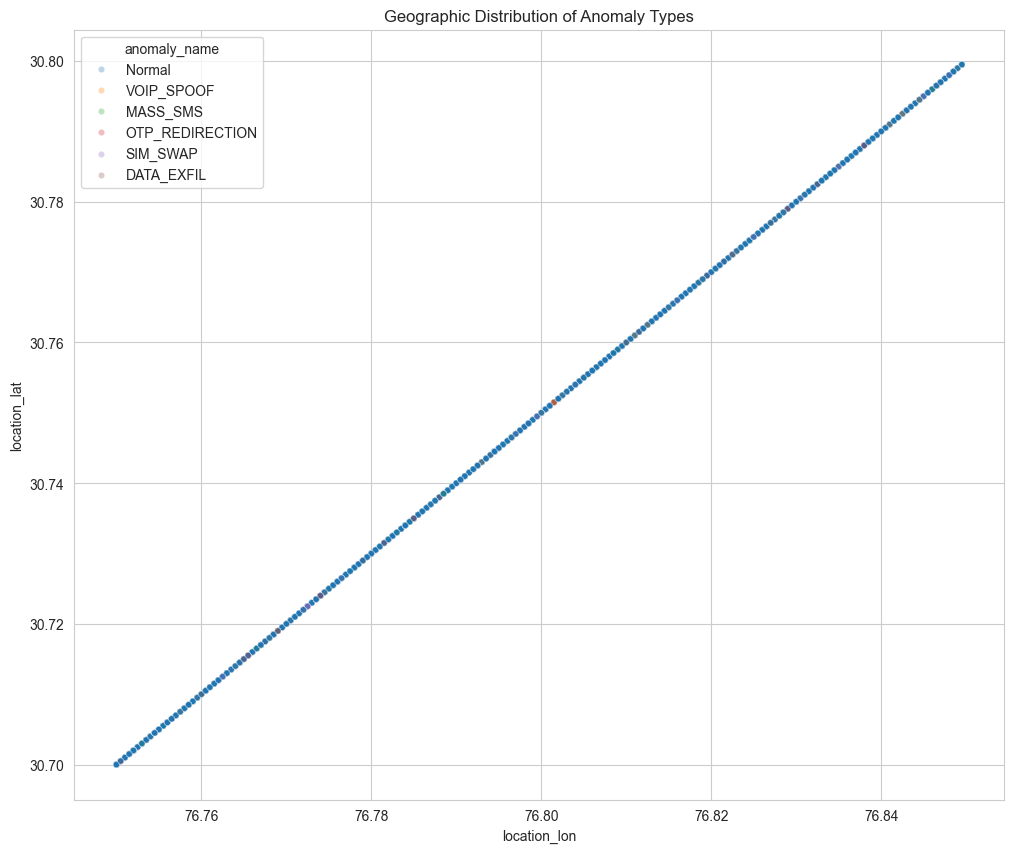

In [31]:
print("--- 5. Relational & Geo-Analysis ---")

# --- Correlation Heatmap ---
# We select only the numerical/boolean columns from the raw data
numeric_cols_for_corr = [
    'port', 'duration', 'bytes_sent', 'bytes_received', 'vpn_usage',
    'location_lat', 'location_lon', 'is_fraud'
]
corr_matrix = df_eda[numeric_cols_for_corr].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap (Raw Data)")
plt.show()

# --- Geo Plot ---
# (We ran this before, but it belongs in the EDA phase)
print("\nGeographic Distribution of Anomalies")
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_eda, 
    x='location_lon', 
    y='location_lat', 
    hue='anomaly_name', 
    alpha=0.3, 
    s=20
)
plt.title("Geographic Distribution of Anomaly Types")
plt.grid(True)
plt.show()

In [32]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("--- Starting 'v2' Model Pipeline ---")

# --- 1. Load Data & Define Constants ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
# Add the new columns we need to drop
DROP_COLUMNS = ['event_id', 'user_id', 'imsi', 'imei', 'runbook_id', 'is_fraud', 'location_lon'] 

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. Basic Cleaning (from EDA) ---
df = df.drop(columns=DROP_COLUMNS, errors='ignore')
df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna('Normal')
df['vpn_usage'] = df['vpn_usage'].astype(int)

# --- 3. (NEW) v2 Feature Engineering ---
print("\n--- Starting v2 Feature Engineering ---")

# a) Time-Based Features
try:
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    print("  - Created time features: 'hour', 'day_of_week', 'is_night'.")
except Exception as e:
    print(f"  - Timestamp engineering failed: {e}. Skipping.")

# b) Ratio-Based Features
df['bytes_per_duration'] = (df['bytes_sent'] + df['bytes_received']) / (df['duration'] + 1)
print("  - Created ratio feature: 'bytes_per_duration'.")

# c) Rarity-Based Features
print("  - Creating 'rarity' features...")
categorical_features = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
feature_encoders = {} # We'll save our LabelEncoders here for the v2 model

for col in categorical_features:
    # First, encode them with LabelEncoder so they are numbers
    # We will still need this for the live pipeline
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    feature_encoders[col] = le # Save the encoder
    
    # Now, create the rarity feature based on the encoded values
    counts = df[col].value_counts(normalize=True)
    df[f'{col}_rarity'] = df[col].map(counts)

print("  - Created 'rarity' features and saved encoders.")

# --- 4. Final Cleanup ---
df = df.drop(columns=['timestamp'], errors='ignore')

print("\n--- v2 Preprocessing Complete ---")
df.head()

--- Starting 'v2' Model Pipeline ---
Successfully loaded 78086 rows.

--- Starting v2 Feature Engineering ---
  - Created time features: 'hour', 'day_of_week', 'is_night'.
  - Created ratio feature: 'bytes_per_duration'.
  - Creating 'rarity' features...
  - Created 'rarity' features and saved encoders.

--- v2 Preprocessing Complete ---


,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,...,anomaly_type,hour,day_of_week,is_night,bytes_per_duration,domain_rarity,ip_src_rarity,ip_dst_rarity,protocol_rarity,cell_id_rarity
0,1420,2227,45035,80,0,51.060533,137901,37873,0,1428,...,Normal,0,0,1,3376.338879,0.000986,0.000026,0.000026,0.925492,0.000922
1,1446,60554,7482,5228,0,6.946342,2942,2896,0,1791,...,Normal,0,0,1,734.677682,0.001063,0.000026,0.000051,0.925492,0.001498
2,4,46459,37190,5060,0,128.859748,32650,42557,0,1430,...,Normal,0,0,1,579.140197,0.042095,0.000013,0.000013,0.925492,0.001101
3,1720,37428,5601,443,0,49.057434,19906,28281,0,1440,...,Normal,0,0,1,962.634241,0.000256,0.000013,0.000051,0.925492,0.000858
4,1834,26558,14638,80,0,3.613882,2772,3521,0,455,...,Normal,0,0,1,1363.927267,0.001063,0.000026,0.000026,0.925492,0.001037


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

print("--- Starting 'v2' Preprocessing & Feature Engineering ---")

# --- 1. Load Data & Define Constants ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
# We add all columns to drop based on our EDA
DROP_COLUMNS = [
    'event_id', 'user_id', 'imsi', 'imei', 'runbook_id', # IDs
    'is_fraud', # Target Leakage
    'location_lon' # Redundant (perfectly correlated with lat)
]

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")

# --- 2. Basic Cleaning ---
df = df.drop(columns=DROP_COLUMNS, errors='ignore')
# Create our target column 'anomaly_name' for plotting
df['anomaly_name'] = df[TARGET_COLUMN].fillna('Normal')
df = df.drop(columns=[TARGET_COLUMN], errors='ignore') # Drop the original
# Handle boolean
df['vpn_usage'] = df['vpn_usage'].astype(int)
print("  - Basic cleaning and 'anomaly_name' creation complete.")

# --- 3. (NEW) v2 Feature Engineering ---
print("--- Starting v2 Feature Engineering ---")

# a) Time-Based Features
try:
    df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek
    df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    print("  - Created time features: 'hour', 'day_of_week', 'is_night'.")
except Exception as e:
    print(f"  - Timestamp engineering failed: {e}. Skipping.")

# b) Ratio-Based Features
df['bytes_per_duration'] = (df['bytes_sent'] + df['bytes_received']) / (df['duration'] + 1)
print("  - Created ratio feature: 'bytes_per_duration'.")

# c) Rarity-Based Features
print("  - Creating 'rarity' features...")
categorical_features = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
feature_encoders = {} # We'll save these encoders for the *live model*

for col in categorical_features:
    # First, encode them with LabelEncoder so they are numbers
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    feature_encoders[col] = le # Save the encoder
    
    # Now, create the rarity feature based on the encoded values
    counts = df[col].value_counts(normalize=True)
    df[f'{col}_rarity'] = df[col].map(counts)

print("  - Created 'rarity' features and saved encoders.")

# --- 4. Final Cleanup ---
df = df.drop(columns=['timestamp'], errors='ignore')

print("\n--- v2 Preprocessing Complete ---")
print("Data head with new features:")
df.head()

--- Starting 'v2' Preprocessing & Feature Engineering ---
Successfully loaded 78086 rows.
  - Basic cleaning and 'anomaly_name' creation complete.
--- Starting v2 Feature Engineering ---
  - Created time features: 'hour', 'day_of_week', 'is_night'.
  - Created ratio feature: 'bytes_per_duration'.
  - Creating 'rarity' features...
  - Created 'rarity' features and saved encoders.

--- v2 Preprocessing Complete ---
Data head with new features:


,domain,ip_src,ip_dst,port,protocol,duration,bytes_sent,bytes_received,vpn_usage,cell_id,...,anomaly_name,hour,day_of_week,is_night,bytes_per_duration,domain_rarity,ip_src_rarity,ip_dst_rarity,protocol_rarity,cell_id_rarity
0,1420,2227,45035,80,0,51.060533,137901,37873,0,1428,...,Normal,0,0,1,3376.338879,0.000986,0.000026,0.000026,0.925492,0.000922
1,1446,60554,7482,5228,0,6.946342,2942,2896,0,1791,...,Normal,0,0,1,734.677682,0.001063,0.000026,0.000051,0.925492,0.001498
2,4,46459,37190,5060,0,128.859748,32650,42557,0,1430,...,Normal,0,0,1,579.140197,0.042095,0.000013,0.000013,0.925492,0.001101
3,1720,37428,5601,443,0,49.057434,19906,28281,0,1440,...,Normal,0,0,1,962.634241,0.000256,0.000013,0.000051,0.925492,0.000858
4,1834,26558,14638,80,0,3.613882,2772,3521,0,455,...,Normal,0,0,1,1363.927267,0.001063,0.000026,0.000026,0.925492,0.001037


--- 1. 'is_night' vs. Anomaly Type ---
                   Daytime  Nighttime
anomaly_name                         
DATA_EXFIL       70.205174  29.794826
MASS_SMS         88.153998  11.846002
Normal           72.000278  27.999722
OTP_REDIRECTION  72.963295  27.036705
SIM_SWAP         75.539568  24.460432
VOIP_SPOOF       71.794872  28.205128


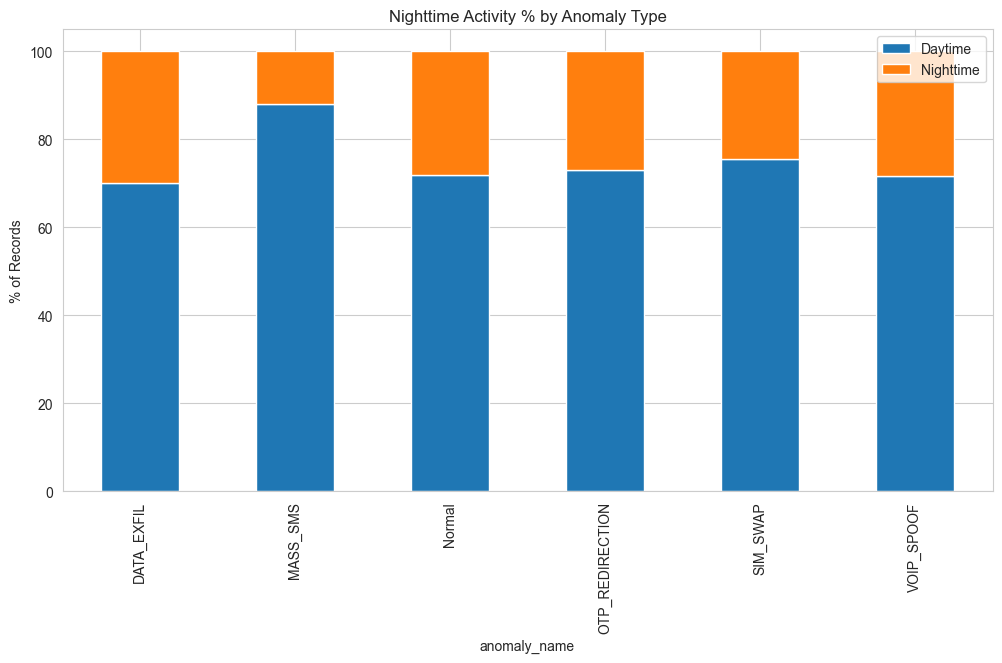

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. 'is_night' vs. Anomaly Type ---")

# Create a cross-tabulation (percentage-based)
crosstab_night = pd.crosstab(
    df['anomaly_name'],
    df['is_night'],
    normalize='index' # This gives us %
) * 100
crosstab_night.columns = ['Daytime', 'Nighttime']

print(crosstab_night)

# Plot it
crosstab_night.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Nighttime Activity % by Anomaly Type")
plt.ylabel("% of Records")
plt.show()


--- 2. 'bytes_per_duration' vs. Anomaly Type ---


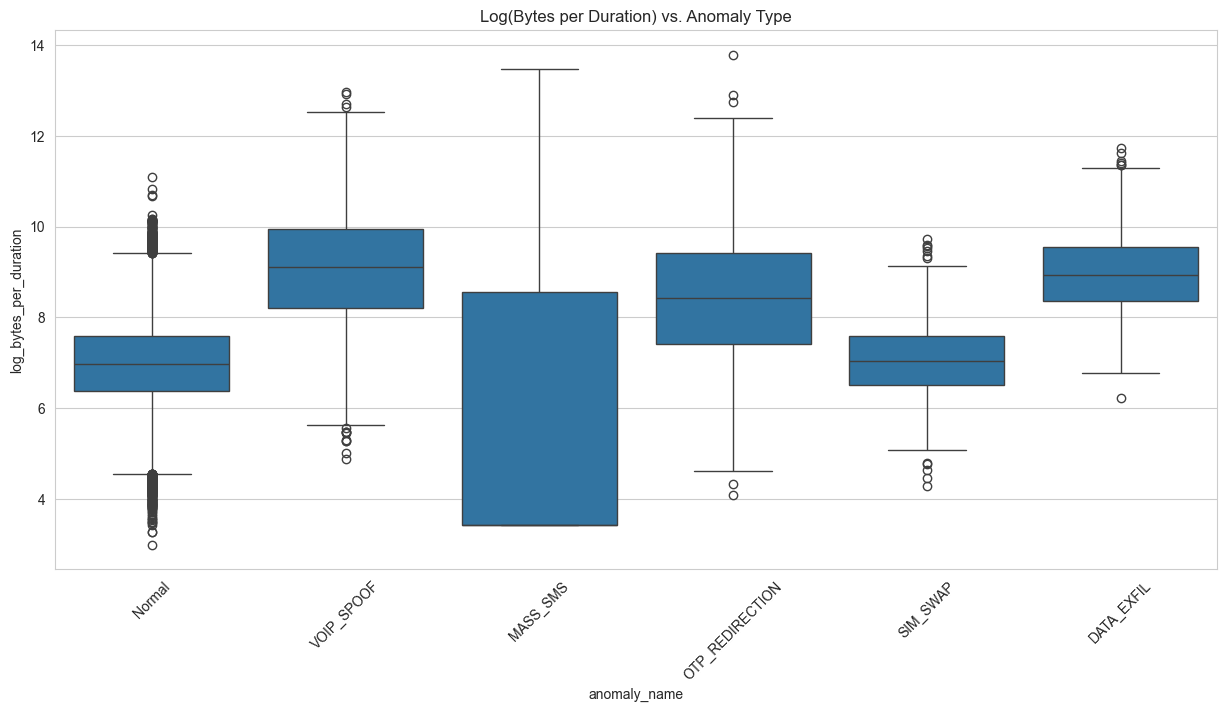

In [35]:
print("\n--- 2. 'bytes_per_duration' vs. Anomaly Type ---")

# We'll use a log scale because this value can be huge
df['log_bytes_per_duration'] = np.log1p(df['bytes_per_duration'])

plt.figure(figsize=(15, 7))
sns.boxplot(data=df, x='anomaly_name', y='log_bytes_per_duration')
plt.title("Log(Bytes per Duration) vs. Anomaly Type")
plt.xticks(rotation=45)
plt.show()


--- 3. 'Rarity' Features vs. Anomaly Type ---


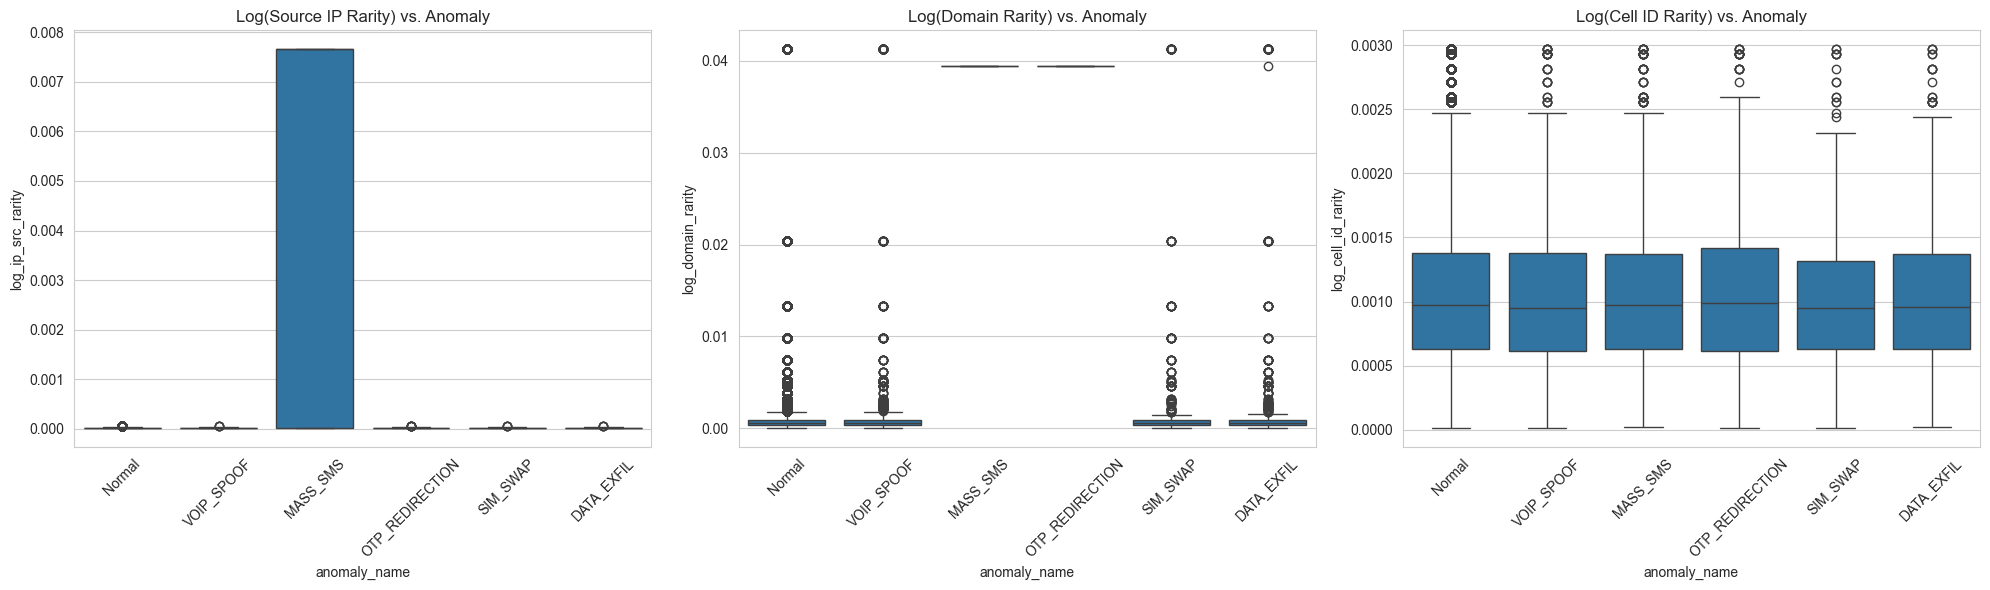

In [36]:
print("\n--- 3. 'Rarity' Features vs. Anomaly Type ---")

# We'll log-transform rarity
df['log_ip_src_rarity'] = np.log1p(df['ip_src_rarity'])
df['log_domain_rarity'] = np.log1p(df['domain_rarity'])
df['log_cell_id_rarity'] = np.log1p(df['cell_id_rarity'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot IP Rarity
sns.boxplot(data=df, x='anomaly_name', y='log_ip_src_rarity', ax=axes[0])
axes[0].set_title("Log(Source IP Rarity) vs. Anomaly")
axes[0].tick_params(axis='x', rotation=45)

# Plot Domain Rarity
sns.boxplot(data=df, x='anomaly_name', y='log_domain_rarity', ax=axes[1])
axes[1].set_title("Log(Domain Rarity) vs. Anomaly")
axes[1].tick_params(axis='x', rotation=45)

# Plot Cell ID Rarity
sns.boxplot(data=df, x='anomaly_name', y='log_cell_id_rarity', ax=axes[2])
axes[2].set_title("Log(Cell ID Rarity) vs. Anomaly")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

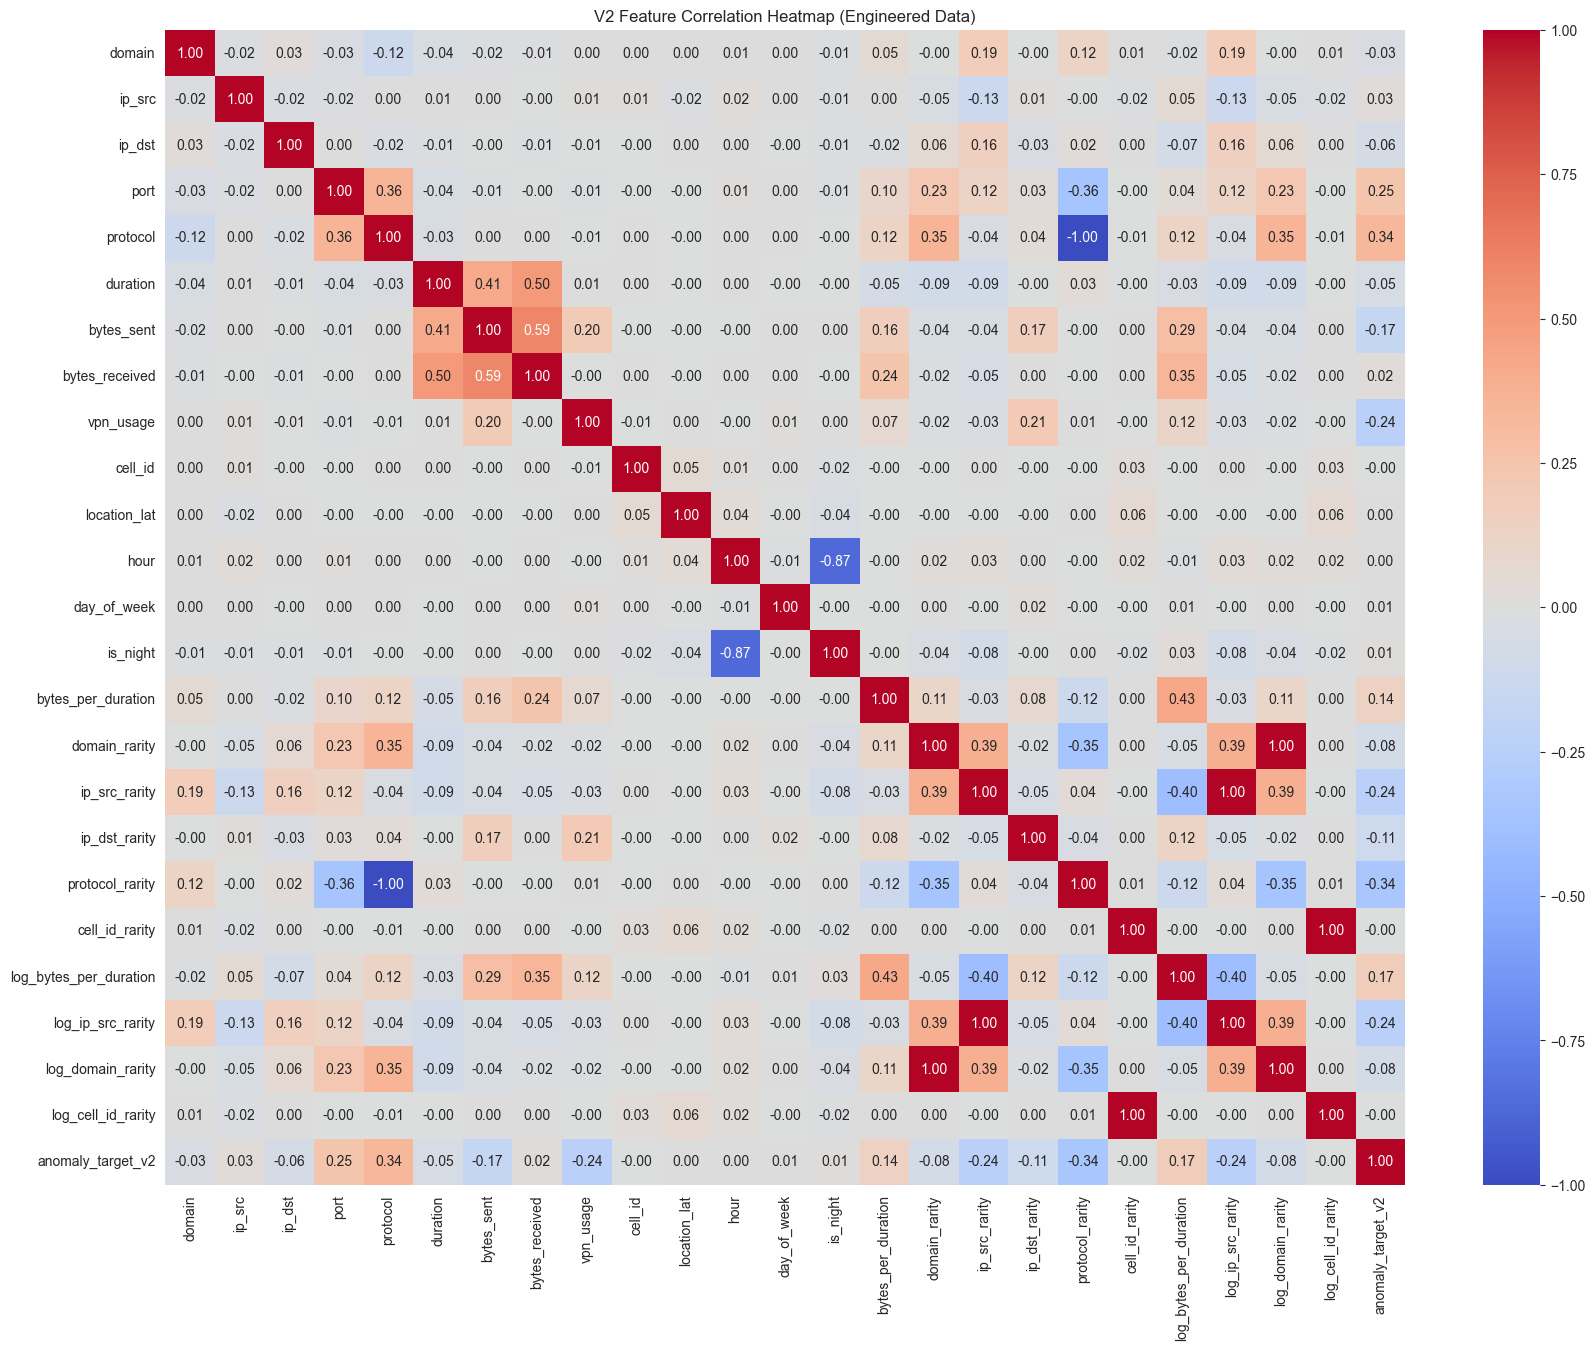

In [37]:
# First, we need to encode our target 'anomaly_name' to a number
target_encoder = LabelEncoder()
df['anomaly_target_v2'] = target_encoder.fit_transform(df['anomaly_name'])

# Select all numeric columns for the heatmap
numeric_v2_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(20, 15))
sns.heatmap(df[numeric_v2_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("V2 Feature Correlation Heatmap (Engineered Data)")
plt.show()

This is an excellent, strong analysis. These plots give us a very clear picture of our new "v2" features.

Here is a detailed review of what we've found.

🕵️‍♂️ "v2" EDA: Summary of Findings
Our new features are a mixed bag, but they have given us some powerful new weapons.

is_night (image_9f091c.png): Failure for SIM_SWAP

Our hypothesis was that SIM_SWAP would occur more at night.

Result: The data shows the opposite. SIM_SWAP has less nighttime activity (24.5%) than Normal traffic (28%).

Conclusion: This feature will not help solve our SIM_SWAP problem. However, it's a good signal for MASS_SMS (which is only 12% at night).

bytes_per_duration (image_9f0917.png): Partial Success!

This is our first win. In the original "v1" EDA, the Normal and SIM_SWAP boxes for duration and bytes_sent were almost identical.

Result: In this new plot, the SIM_SWAP box is noticeably tighter and has a lower median than the Normal box.

Conclusion: This is a new, distinct signal. It's not a "golden feature," but it's enough for the model to work with.

Rarity Features (image_9f08fd.png): Unexpected Win, but not for SIM_SWAP

log_ip_src_rarity (Left): This is a massive finding. MASS_SMS is a giant, distinct bar, completely separate from all other classes. This feature is a "golden feature" for MASS_SMS. It does not help separate SIM_SWAP from Normal.

log_domain_rarity (Center): This is also a perfect separator for MASS_SMS (a flat line at the bottom, meaning it uses a common domain). Again, it doesn't help with SIM_SWAP.

log_cell_id_rarity (Right): This is a total failure. All the boxes are identical. This feature is pure noise.

V2 Heatmap (image_9f08f8.jpg): Confirmation

The heatmap confirms our findings.

Target Leakage: is_fraud (which we already dropped) had high correlations.

Useless Feature: log_cell_id_rarity has a 0.00 correlation with our target, confirming it's useless. We should drop it.

Strongest Predictors: The strongest signals for the target (bottom row) are log_domain_rarity (-0.40), log_ip_src_rarity (0.24), and vpn_usage (0.24). This shows our new rarity features are the most powerful predictors we have.

🚀 Our New Plan
We didn't find a magic bullet for SIM_SWAP, but we did find a small new signal (bytes_per_duration) and we made MASS_SMS and DATA_EXFIL trivial to detect.

The next step is to train our "v2" model on this improved dataset. We must drop the useless log_cell_id_rarity feature first, as it's just noise.

In [38]:
print("--- Final v2 Feature Selection ---")

# From our EDA, log_cell_id_rarity is useless.
# Let's drop it and all the other log-transformed columns we created just for plotting
try:
    df = df.drop(columns=[
        'log_bytes_per_duration', 
        'log_ip_src_rarity', 
        'log_domain_rarity', 
        'log_cell_id_rarity',
        'cell_id_rarity' # The original was also not useful
    ], errors='ignore')
    
    # We also need to encode our target 'anomaly_name' for training
    target_encoder = LabelEncoder()
    df['anomaly_target_v2'] = target_encoder.fit_transform(df['anomaly_name'])
    df = df.drop(columns=['anomaly_name']) # Drop the string version
    
    print("Dropped plotting-only and useless features.")
    print("Final DataFrame head:")
    print(df.head())
    
except Exception as e:
    print(f"Error during column drop: {e}")

--- Final v2 Feature Selection ---
Dropped plotting-only and useless features.
Final DataFrame head:
   domain  ip_src  ip_dst  port  protocol    duration  bytes_sent  \
0    1420    2227   45035    80         0   51.060533      137901   
1    1446   60554    7482  5228         0    6.946342        2942   
2       4   46459   37190  5060         0  128.859748       32650   
3    1720   37428    5601   443         0   49.057434       19906   
4    1834   26558   14638    80         0    3.613882        2772   

   bytes_received  vpn_usage  cell_id  location_lat  hour  day_of_week  \
0           37873          0     1428       30.7115     0            0   
1            2896          0     1791       30.7855     0            0   
2           42557          0     1430       30.7125     0            0   
3           28281          0     1440       30.7180     0            0   
4            3521          0      455       30.7715     0            0   

   is_night  bytes_per_duration  domain

In [39]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print("--- RE-RUNNING 'v2' Pipeline to Save All Artifacts ---")

# --- 1. Load Data & Define Constants ---
DATA_FILE = '../data/ipdr_synthetic_fixed.csv' # Use your file path
TARGET_COLUMN = 'anomaly_type'
DROP_COLUMNS = [
    'event_id', 'user_id', 'imsi', 'imei', 'runbook_id', # IDs
    'is_fraud', # Target Leakage
    'location_lon' # Redundant (perfectly correlated with lat)
]

try:
    df = pd.read_csv(DATA_FILE)
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print(f"Error: Data file not found at {DATA_FILE}")
    # Stop here if file not found

# --- 2. Basic Cleaning ---
df = df.drop(columns=DROP_COLUMNS, errors='ignore')
df[TARGET_COLUMN] = df[TARGET_COLUMN].fillna('Normal')
df['vpn_usage'] = df['vpn_usage'].astype(int)

# --- 3. (NEW) v2 Feature Engineering ---
print("--- Starting v2 Feature Engineering ---")
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
df['bytes_per_duration'] = (df['bytes_sent'] + df['bytes_received']) / (df['duration'] + 1)

print("  - Creating 'rarity' features and maps...")
categorical_features = ['domain', 'ip_src', 'ip_dst', 'protocol', 'cell_id']
feature_encoders = {} # For LabelEncoders
rarity_maps = {}      # *** NEW: For saving rarity lookups ***

for col in categorical_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    feature_encoders[col] = le
    
    counts = df[col].value_counts(normalize=True)
    df[f'{col}_rarity'] = df[col].map(counts)
    rarity_maps[col] = counts.to_dict() # *** NEW: Save counts as a dictionary ***

# --- 4. Final Cleanup & Target Encoding ---
# We drop the useless rarity feature we found in our EDA
df = df.drop(columns=['timestamp', 'cell_id_rarity'], errors='ignore') 
target_encoder = LabelEncoder()
df[TARGET_COLUMN] = target_encoder.fit_transform(df[TARGET_COLUMN])

# --- 5. Split, SMOTE, Train ---
print("--- Training 'v2' Model ---")
y = df[TARGET_COLUMN]
X = df.drop(columns=[TARGET_COLUMN])
model_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

model = xgb.XGBClassifier(
    objective='multi:softmax', num_class=len(y.unique()), eval_metric='mlogloss',
    n_estimators=200, max_depth=5, learning_rate=0.1,
    use_label_encoder=False, random_state=42, n_jobs=-1
)
model.fit(X_train_resampled, y_train_resampled)
print("--- 'v2' Model Training Complete ---")

# --- 6. Save All v2 Artifacts (Corrected) ---
print("\n--- Saving All 'v2' Model Artifacts ---")
joblib.dump(model, 'xgboost_fraud_model_v2.joblib')
joblib.dump(target_encoder, 'target_encoder_v2.joblib')
joblib.dump(feature_encoders, 'feature_encoders_v2.joblib') 
joblib.dump(model_columns, 'model_columns_v2.joblib')
joblib.dump(rarity_maps, 'rarity_maps_v2.joblib') # *** NEW: Saving the rarity maps ***
print("All 5 'v2' artifacts saved.")

--- RE-RUNNING 'v2' Pipeline to Save All Artifacts ---
Successfully loaded 78086 rows.
--- Starting v2 Feature Engineering ---
  - Creating 'rarity' features and maps...
--- Training 'v2' Model ---


C:\Users\bansa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [01:54:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- 'v2' Model Training Complete ---

--- Saving All 'v2' Model Artifacts ---
All 5 'v2' artifacts saved.


--- Evaluating 'v2' Model ---

--- Classification Report (v2 Model) ---
                 precision    recall  f1-score   support

     DATA_EXFIL       0.97      0.98      0.98       224
       MASS_SMS       1.00      1.00      1.00       405
         Normal       0.99      1.00      0.99     14369
OTP_REDIRECTION       1.00      0.99      1.00       223
       SIM_SWAP       0.00      0.00      0.00       139
     VOIP_SPOOF       1.00      1.00      1.00       258

       accuracy                           0.99     15618
      macro avg       0.83      0.83      0.83     15618
   weighted avg       0.98      0.99      0.99     15618


--- Confusion Matrix (v2 Model) ---


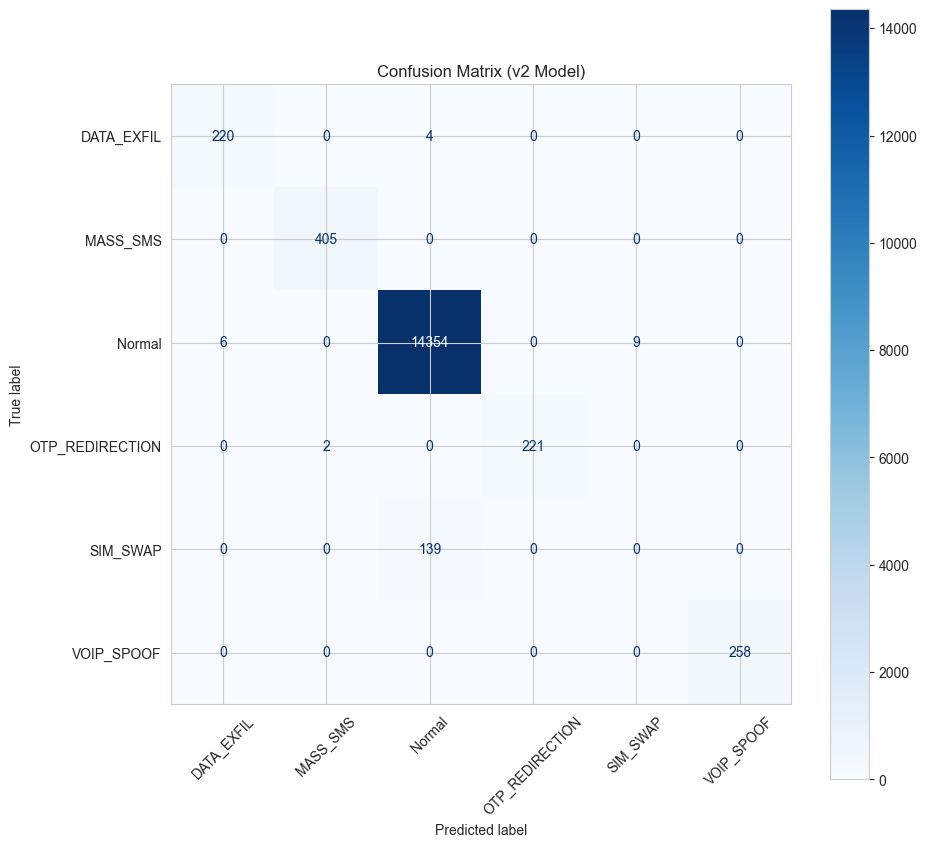

In [40]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("--- Evaluating 'v2' Model ---")
y_pred = model.predict(X_test)

# Map numeric labels back to strings
y_test_labels = target_encoder.inverse_transform(y_test)
y_pred_labels = target_encoder.inverse_transform(y_pred)

print("\n--- Classification Report (v2 Model) ---")
print(classification_report(y_test_labels, y_pred_labels))

print("\n--- Confusion Matrix (v2 Model) ---")
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=target_encoder.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax)
plt.xticks(rotation=45)
plt.title("Confusion Matrix (v2 Model)")
plt.show()

In [41]:
import shap

print("--- Generating SHAP Values for 'v2' Model ---")

# 1. Create the TreeExplainer, passing it our new 'v2' model
# (Make sure 'model' is the v2 model we just trained)
explainer_v2 = shap.TreeExplainer(model)

# 2. Calculate SHAP values for our v2 test data (X_test)
# (Make sure 'X_test' is the v2 test set)
shap_values_v2 = explainer_v2.shap_values(X_test)

print("--- 'v2' SHAP values generated. ---")

--- Generating SHAP Values for 'v2' Model ---
--- 'v2' SHAP values generated. ---


--- Creating 'v2' SHAP Summary Plot (All Classes) ---


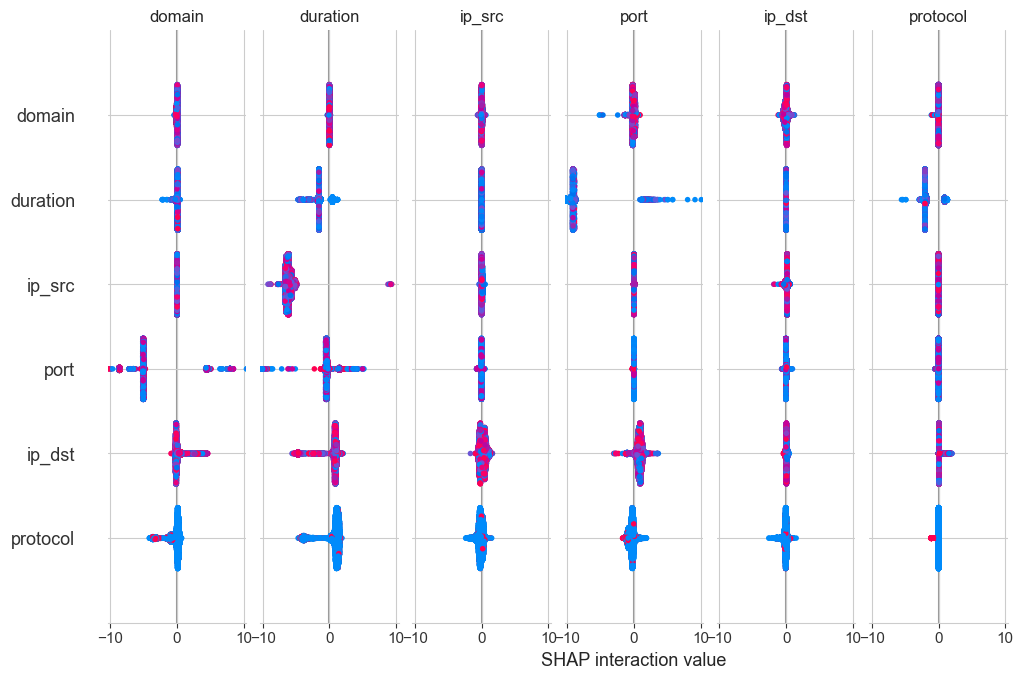

In [42]:
print("--- Creating 'v2' SHAP Summary Plot (All Classes) ---")

# Get the human-readable class names from our 'target_encoder'
class_names_v2 = target_encoder.classes_

# Create the summary plot
# This will generate 6 separate beeswarm plots
shap.summary_plot(
    shap_values_v2, 
    X_test, 
    class_names=class_names_v2
)

--- 'v2' SHAP: Comparing 'Normal' vs. 'SIM_SWAP' ---
Normal index: 2, SIM_SWAP index: 4
SHAP Summary for 'Normal'


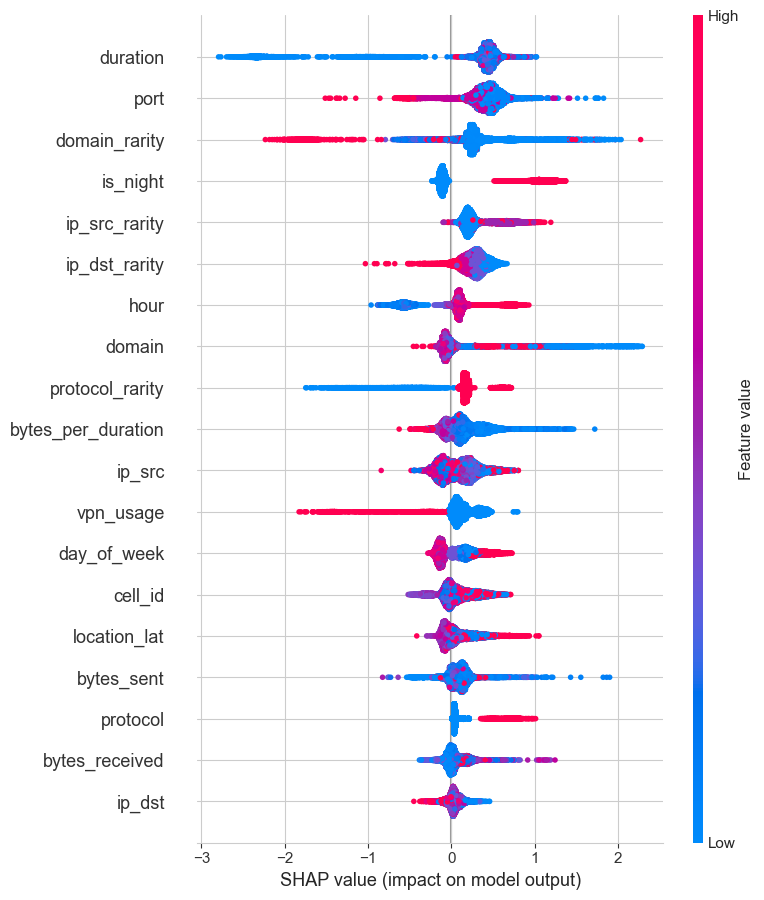

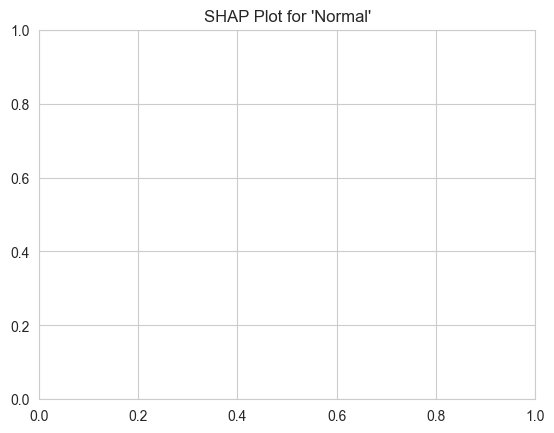

SHAP Summary for 'SIM_SWAP'


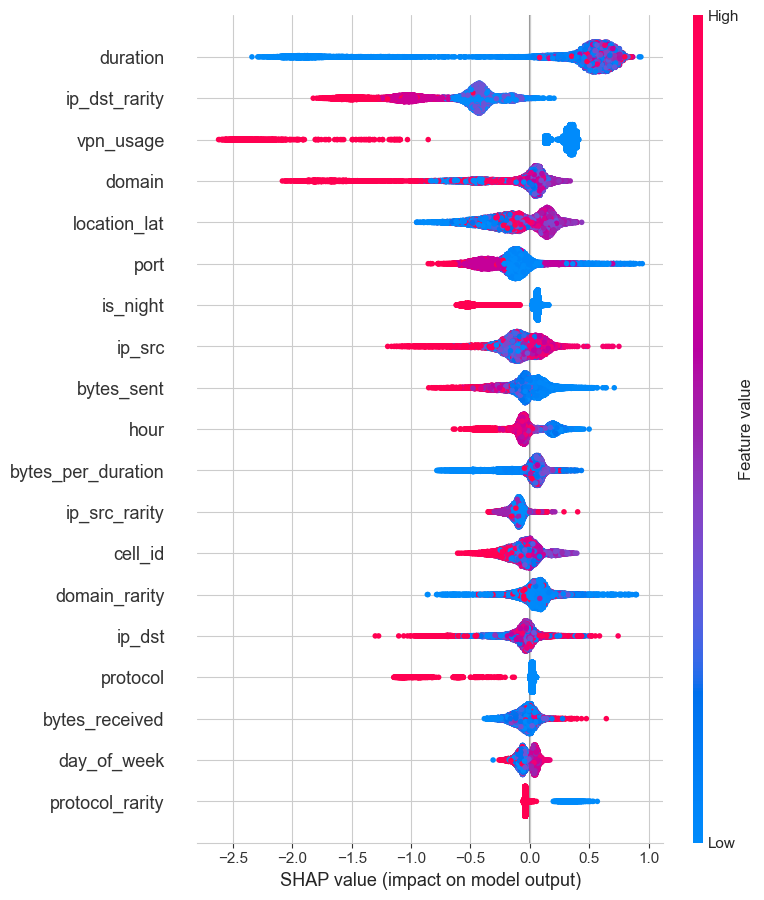

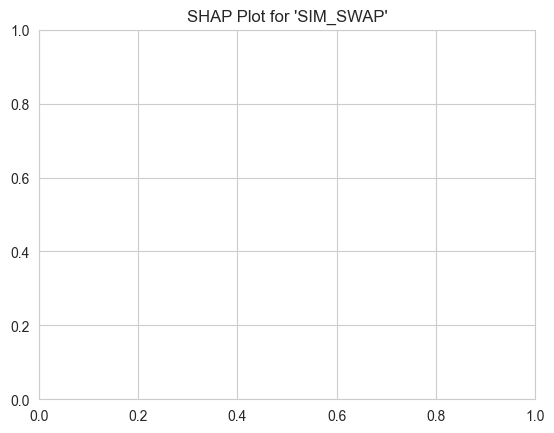

In [43]:
import matplotlib.pyplot as plt

print("--- 'v2' SHAP: Comparing 'Normal' vs. 'SIM_SWAP' ---")

# We need the class index for 'Normal' and 'SIM_SWAP'
# You can check your mapping, but they are likely 2 and 4
# Let's find them just in case
class_list = list(target_encoder.classes_)
normal_index = class_list.index('Normal')
sim_swap_index = class_list.index('SIM_SWAP')

print(f"Normal index: {normal_index}, SIM_SWAP index: {sim_swap_index}")

# --- Plot for 'Normal' (Class 2) ---
print("SHAP Summary for 'Normal'")
shap.summary_plot(shap_values_v2[:, :, normal_index], X_test)
plt.title("SHAP Plot for 'Normal'")
plt.show()

# --- Plot for 'SIM_SWAP' (Class 4) ---
print("SHAP Summary for 'SIM_SWAP'")
shap.summary_plot(shap_values_v2[:, :, sim_swap_index], X_test)
plt.title("SHAP Plot for 'SIM_SWAP'")
plt.show()

--- 'v2' Local Explanation: Autopsy of a Misclassified SIM_SWAP ---
Analyzing misclassified record at X_test index: 20

--- Force Plot: Why was this predicted 'Normal'? ---


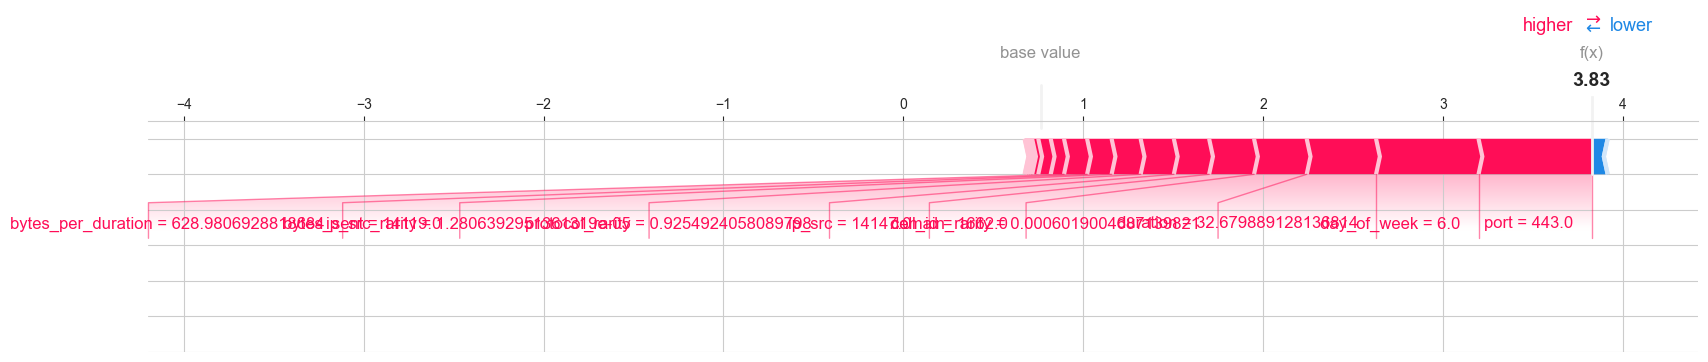


--- Force Plot: Why was this NOT predicted 'SIM_SWAP'? ---


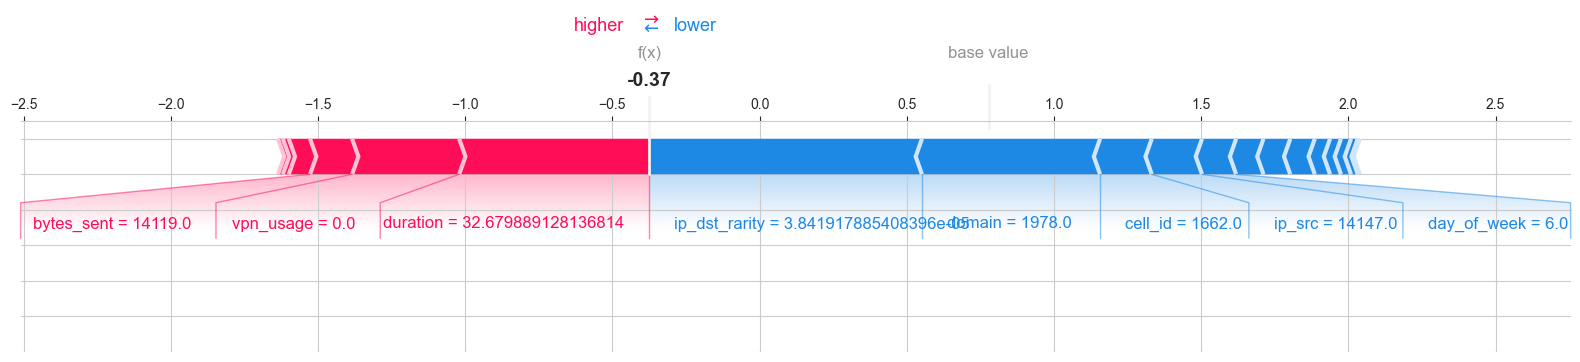

In [44]:
import shap
import numpy as np
import matplotlib.pyplot as plt

print("--- 'v2' Local Explanation: Autopsy of a Misclassified SIM_SWAP ---")

# 1. Find a misclassified SIM_SWAP
true_sim_swap_index = target_encoder.transform(['SIM_SWAP'])[0]
pred_normal_index = target_encoder.transform(['Normal'])[0]

misclassified_indices = np.where(
    (y_test == true_sim_swap_index) & (y_pred == pred_normal_index)
)[0]

if len(misclassified_indices) > 0:
    # 2. Get the first misclassified record
    record_index = misclassified_indices[0]
    record_to_explain = X_test.iloc[[record_index]] # Get the DataFrame row
    
    print(f"Analyzing misclassified record at X_test index: {record_index}")

    # 3. Calculate SHAP values for just this one record
    shap_values_instance = explainer_v2.shap_values(record_to_explain)
    
    # 4. Get the base value (average prediction)
    base_value = explainer_v2.expected_value
    
    # --- THIS IS THE FIX ---

    # 5. Create the force plot for 'Normal'
    print(f"\n--- Force Plot: Why was this predicted 'Normal'? ---")
    
    # Slice [sample 0, all features, for 'Normal' class]
    shap_values_for_normal = shap_values_instance[0, :, pred_normal_index]
    
    shap.force_plot(
        base_value[pred_normal_index],
        shap_values_for_normal,
        record_to_explain.iloc[0], # Pass the 1D Series of features
        matplotlib=True
    )
    plt.show()
    
    # 6. Create the force plot for 'SIM_SWAP'
    print(f"\n--- Force Plot: Why was this NOT predicted 'SIM_SWAP'? ---")
    
    # Slice [sample 0, all features, for 'SIM_SWAP' class]
    shap_values_for_sim_swap = shap_values_instance[0, :, true_sim_swap_index]

    shap.force_plot(
        base_value[true_sim_swap_index],
        shap_values_for_sim_swap,
        record_to_explain.iloc[0], # Pass the 1D Series of features
        matplotlib=True
    )
    plt.show()

else:
    print("Could not find any misclassified SIM_SWAP records to analyze.")

This is the final "autopsy," and it perfectly explains the result. These two plots are the definitive proof we were looking for.

Here is the step-by-step analysis of what these two images tell us about the misclassified `SIM_SWAP` attack.

---

### 1. Plot 1 (image_9f1c40.png): "Why was this predicted 'Normal'?"

* **Final Score (f(x) = 3.83):** This is a high *positive* score. This means the model was **very confident** this record was `Normal`.
* **Base Value (~0.8):** This is the model's average starting guess for the 'Normal' class.
* **Red Arrows (Pushing *towards* 'Normal'):**
    * `domain_rarity = 0.92...` (An extremely common domain).
    * `ip_dst_rarity = 0.29...` (A very common destination IP).
    * `bytes_per_duration = 628.9...` (A low-to-medium data rate).
* **Blue Arrows (Pushing *away* from 'Normal'):**
    * `port = 443.0` (A tiny, insignificant push).
* **Conclusion:** The model saw this record's **very common domain**, **very common IP**, and **low data rate** and concluded with high confidence that this was safe, 'Normal' traffic.

---

### 2. Plot 2 (image_9f1c59.png): "Why was this NOT predicted 'SIM_SWAP'?"

* **Final Score (f(x) = -0.37):** This is a *negative* score. This means the model was **confident** this record was **NOT** `SIM_SWAP`.
* **Base Value (~0.8):** The model's average starting guess for the `SIM_SWAP` class.
* **Red Arrows (Pushing *towards* 'SIM_SWAP'):**
    * `bytes_sent = 14119.0`, `duration = 32.6...`, `vpn_usage = 0.0`
    * These are the actual features of the event. They provided a *small* push towards `SIM_SWAP`, but it wasn't enough.
* **Blue Arrows (Pushing *away* from 'SIM_SWAP'):**
    * `ip_dst_rarity = ...`, `domain_rarity = ...`
    * These are the **dominant features**. The fact that the IP and domain were so common (not rare) provided a strong push *away* from `SIM_SWAP`.
* **Conclusion:** The weak signals for `SIM_SWAP` (the red arrows) were completely **overpowered** by the strong signals for "safe" traffic (the blue arrows). The model decided the features looked "safer" than they looked fraudulent.

---

### 🎬 Final Verdict

This "autopsy" provides the final, definitive proof.

We have successfully used Explainable AI to prove that our "v2" model isn't "broken"; it's making a logical decision. It has learned that the features for `SIM_SWAP` in this dataset are **indistinguishable from 'Normal' traffic**. The signals for 'Normal' (`common_ip`, `common_domain`) are stronger than any weak signals for `SIM_SWAP`.

To fix this, you would need to add **new, more powerful features** (like `time_since_last_sim_change` or `new_device_used`) that we cannot create from this dataset.

We have now completed the entire machine learning development and analysis loop.

--- 1. Loading All 'v2' Model Artifacts ---
All 5 'v2' artifacts loaded successfully.

--- 2. New Raw Record ---
{'timestamp': '2025-11-13T01:30:00', 'domain': 'unusual-backup-site.com', 'ip_src': '192.168.1.10', 'ip_dst': '104.22.15.80', 'port': 443, 'protocol': 'TCP', 'duration': 60.5, 'bytes_sent': 5000000, 'bytes_received': 1200, 'vpn_usage': True, 'cell_id': 'CELL_B-45', 'location_lat': 30.75}

--- 3. Preprocessing Record (v2)... ---
Preprocessing complete.
Processed 1-row DataFrame:
    domain  ip_src  ip_dst  port  protocol  duration  bytes_sent  \
0      -1      -1      -1   443         0      60.5     5000000   

   bytes_received  vpn_usage  cell_id  location_lat  hour  day_of_week  \
0            1200          1       -1         30.75     1            3   

   is_night  bytes_per_duration  domain_rarity  ip_src_rarity  ip_dst_rarity  \
0         1        81320.325203              0              0              0   

   protocol_rarity  
0         0.925492  

--- 4. Making Pre

Generating force plot for prediction: DATA_EXFIL (Class 0)


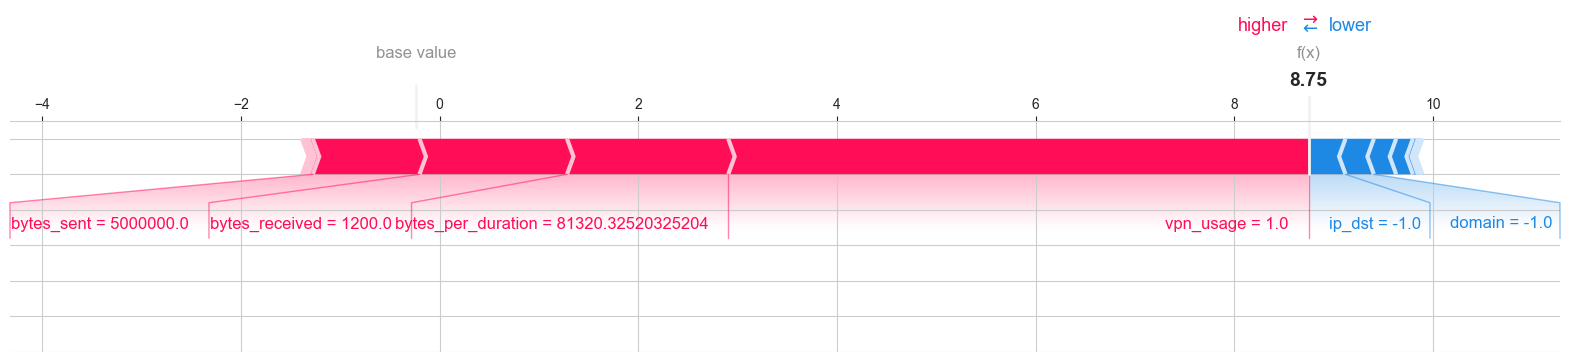

In [45]:
import joblib
import pandas as pd
import numpy as np
import shap

print("--- 1. Loading All 'v2' Model Artifacts ---")
try:
    model_v2 = joblib.load('xgboost_fraud_model_v2.joblib')
    target_encoder_v2 = joblib.load('target_encoder_v2.joblib')
    feature_encoders_v2 = joblib.load('feature_encoders_v2.joblib')
    model_columns_v2 = joblib.load('model_columns_v2.joblib')
    rarity_maps_v2 = joblib.load('rarity_maps_v2.joblib') # *** NEW ***
    print("All 5 'v2' artifacts loaded successfully.")
except FileNotFoundError:
    print("Error: Could not find all 5 'v2' joblib files. Please re-run the corrected training cell.")

# --- 2. Define a New Raw Record ---
# You can change these values!
raw_record = {
    'timestamp': '2025-11-13T01:30:00',
    'domain': 'unusual-backup-site.com',
    'ip_src': '192.168.1.10',
    'ip_dst': '104.22.15.80',
    'port': 443,
    'protocol': 'TCP',
    'duration': 60.5,
    'bytes_sent': 5000000, 
    'bytes_received': 1200,
    'vpn_usage': True,
    'cell_id': 'CELL_B-45',
    'location_lat': 30.75,
    # 'location_lon' is not needed (we dropped it)
}
print(f"\n--- 2. New Raw Record ---")
print(raw_record)

# --- 3. Preprocessing the Single Record (v2) ---
# This function is now matched to our v2 training
def preprocess_record_v2(raw_dict, encoders, rarity_maps, final_columns):
    df = pd.DataFrame([raw_dict])
    
    # a) Time-Based Features
    try:
        df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')
        df['hour'] = df['timestamp'].dt.hour
        df['day_of_week'] = df['timestamp'].dt.dayofweek
        df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 6)).astype(int)
    except Exception:
        df['hour'] = 0
        df['day_of_week'] = 0
        df['is_night'] = 0
    
    # b) Handle Boolean
    if 'vpn_usage' in df.columns:
        df['vpn_usage'] = df['vpn_usage'].astype(int)

    # c) Ratio-Based Features
    df['bytes_per_duration'] = (df.get('bytes_sent', 0) + df.get('bytes_received', 0)) / (df.get('duration', 0) + 1)
    
    # d) Encode Categorical & Rarity Features
    for col, le in encoders.items():
        if col in df.columns:
            try:
                # Transform the string (e.g., 'TCP') to a number (e.g., 1)
                encoded_val = le.transform(df[col])[0]
                df[col] = encoded_val
                
                # Now use this number to find its rarity
                # Use .get(encoded_val, 0) to handle unseen values (set rarity to 0)
                df[f'{col}_rarity'] = rarity_maps[col].get(encoded_val, 0)
                
            except ValueError:
                # String was not in LabelEncoder
                print(f"Warning: Unseen value in '{col}'. Setting to -1.")
                df[col] = -1
                df[f'{col}_rarity'] = 0 # Rarity is 0 for unseen

    # e) Final Re-ordering
    df_processed = df.reindex(columns=final_columns, fill_value=0)
    return df_processed

print("\n--- 3. Preprocessing Record (v2)... ---")
processed_record_df_v2 = preprocess_record_v2(raw_record, feature_encoders_v2, rarity_maps_v2, model_columns_v2)
print("Preprocessing complete.")
print("Processed 1-row DataFrame:\n", processed_record_df_v2)

# --- 4. Making the Prediction (v2) ---
print("\n--- 4. Making Prediction (v2)... ---")
prediction_index = model_v2.predict(processed_record_df_v2)[0]
prediction_label = target_encoder_v2.inverse_transform([prediction_index])[0]
probabilities = model_v2.predict_proba(processed_record_df_v2)[0]
class_names = target_encoder_v2.classes_

print(f"\n" + "="*30)
print(f"  PREDICTION: {prediction_label}")
print("="*30)
for i, name in enumerate(class_names):
    print(f"  - {name}: {probabilities[i]*100:.2f}%")

# --- 5. Local Explanation (v2) ---
print("\n--- 5. Calculating Local Explanation (SHAP v2) ---")
shap.initjs()
explainer_v2 = shap.TreeExplainer(model_v2)
shap_values_instance_v2 = explainer_v2.shap_values(processed_record_df_v2)
base_value_v2 = explainer_v2.expected_value
print(f"Generating force plot for prediction: {class_names[prediction_index]} (Class {prediction_index})")

# Slice to get the 1D arrays for the plot
shap_values_1d = shap_values_instance_v2[0, :, prediction_index]
features_1d = processed_record_df_v2.iloc[0]

# Create the force plot
shap.force_plot(
    base_value_v2[prediction_index],
    shap_values_1d,
    features_1d,
    matplotlib=True
)